<a href="https://colab.research.google.com/github/tabrejansary/ML-Assignments/blob/main/Lab-06/A3_performance%20comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Performance Comparison of 3 k-NN Versions
# All Function Definitions

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
import time
import unittest
import warnings
from google.colab import drive

drive.mount('/content/drive')

class Config:
    DRIVE_DIR = "/content/drive/MyDrive"
    DATASET_DIR = os.path.join(DRIVE_DIR, "BreaKHis_v1")
    CSV_PATH = os.path.join(DRIVE_DIR, "BreaKHis_metadata.csv")
    SAMPLES_PER_CLASS = 100
    IMAGE_SIZE = (16, 16)
    K = 5
    DISTANCE_METRIC = "euclidean"
    SORT_ALGORITHM = "insertion"
    RANDOM_STATE = 42
    TEST_SIZE = 0.2
    NUM_RUNS = 10

def load_dataset(csv_path):
    return pd.read_csv(csv_path)

def resolve_image_path(filename, drive_dir, dataset_dir):
    filename = str(filename).replace("\\", "/")
    path1 = os.path.join(drive_dir, filename)
    if os.path.exists(path1):
        return path1
    path2 = os.path.join(dataset_dir, filename)
    if os.path.exists(path2):
        return path2
    if filename.startswith("BreaKHis_v1/"):
        filename = filename[len("BreaKHis_v1/"):]
        path3 = os.path.join(dataset_dir, filename)
        if os.path.exists(path3):
            return path3
    return None

def extract_class_from_filename(filename):
    filename = str(filename).lower()
    if "/benign/" in filename:
        return "benign"
    elif "/malignant/" in filename:
        return "malignant"
    else:
        return np.nan

def extract_image_features(image_path, image_size=(16, 16)):
    image = Image.open(image_path).convert("L")
    image = image.resize(image_size)
    image_array = np.asarray(image, dtype=float)
    return image_array.flatten()

def prepare_image_dataset(data, samples_per_class, image_size, drive_dir, dataset_dir, random_state):
    data = data.copy()
    data["class"] = data["filename"].apply(extract_class_from_filename)
    data = data.dropna(subset=["class"])

    sampled_data = data.groupby("class", group_keys=False).apply(
        lambda group: group.sample(n=min(samples_per_class, len(group)), random_state=random_state),
        include_groups=False
    ).reset_index(drop=True)

    sampled_data = data.loc[sampled_data.index].copy()
    feature_rows = []
    labels = []

    for _, row in sampled_data.iterrows():
        image_path = resolve_image_path(row["filename"], drive_dir, dataset_dir)
        if image_path is None:
            continue
        try:
            features = extract_image_features(image_path, image_size)
            feature_rows.append(features)
            labels.append(row["class"])
        except Exception:
            continue

    X = pd.DataFrame(feature_rows)
    y = pd.Series(labels, name="class")
    return X, y

def get_dataset_info(X, y):
    return {
        "shape": X.shape if hasattr(X, 'shape') else (len(X), len(X[0])),
        "classes": np.unique(y).tolist(),
        "class_distribution": pd.Series(y).value_counts().to_dict()
    }

def encode_data(data):
    encoded_data = data.copy()
    categorical_columns = encoded_data.select_dtypes(include=["object", "category"]).columns

    for column in categorical_columns:
        categories = encoded_data[column].dropna().unique()
        mapping = {value: index for index, value in enumerate(categories)}
        encoded_data[column] = encoded_data[column].map(mapping)

    return encoded_data

def impute_missing_values(data, method="mean"):
    imputed_data = data.copy()

    for column in imputed_data.columns:
        if imputed_data[column].isnull().any():
            if method == "mean":
                value = imputed_data[column].mean()
            elif method == "median":
                value = imputed_data[column].median()
            elif method == "mode":
                value = imputed_data[column].mode()[0]
            else:
                raise ValueError("Method must be 'mean', 'median', or 'mode'.")
            imputed_data[column] = imputed_data[column].fillna(value)

    return imputed_data

def preprocess_data(X, y, imputation_method="mean"):
    X = impute_missing_values(X, method=imputation_method)
    X = encode_data(X)
    X = X.to_numpy(dtype=float)
    y = y.to_numpy()
    return X, y

def calculate_distance(point1, point2, metric="euclidean"):
    point1 = np.asarray(point1, dtype=float)
    point2 = np.asarray(point2, dtype=float)

    if metric == "euclidean":
        return np.sqrt(np.sum((point1 - point2) ** 2))
    elif metric == "manhattan":
        return np.sum(np.abs(point1 - point2))
    else:
        raise ValueError("Metric must be 'euclidean' or 'manhattan'.")

def bubble_sort(items):
    result = items.copy()
    n = len(result)

    for i in range(n):
        for j in range(0, n - i - 1):
            key1 = (result[j][0], result[j][2])
            key2 = (result[j + 1][0], result[j + 1][2])
            if key1 > key2:
                result[j], result[j + 1] = result[j + 1], result[j]

    return result

def selection_sort(items):
    result = items.copy()
    n = len(result)

    for i in range(n):
        min_index = i
        for j in range(i + 1, n):
            key1 = (result[j][0], result[j][2])
            key2 = (result[min_index][0], result[min_index][2])
            if key1 < key2:
                min_index = j
        result[i], result[min_index] = result[min_index], result[i]

    return result

def insertion_sort(items):
    result = items.copy()

    for i in range(1, len(result)):
        current = result[i]
        j = i - 1

        while j >= 0:
            prev_key = (result[j][0], result[j][2])
            curr_key = (current[0], current[2])
            if prev_key <= curr_key:
                break
            result[j + 1] = result[j]
            j -= 1

        result[j + 1] = current

    return result

def sort_distances(items, algorithm="insertion"):
    if algorithm == "bubble":
        return bubble_sort(items)
    elif algorithm == "selection":
        return selection_sort(items)
    elif algorithm == "insertion":
        return insertion_sort(items)
    else:
        raise ValueError("Algorithm must be 'bubble', 'selection', or 'insertion'.")

def find_neighbors(sorted_distances, k):
    if k <= 0:
        raise ValueError("k must be greater than zero.")
    return sorted_distances[:k]

def get_neighbors_with_distance(X_train, y_train, test_point, metric, algorithm, k):
    distance_list = []
    for idx in range(len(X_train)):
        distance = calculate_distance(test_point, X_train[idx], metric)
        distance_list.append((distance, y_train[idx], idx))

    sorted_distances = sort_distances(distance_list, algorithm)
    return find_neighbors(sorted_distances, k)

def assign_class_majority(neighbors):
    class_counts = Counter()
    for distance, class_label, index in neighbors:
        class_counts[class_label] += 1

    max_votes = max(class_counts.values())
    tied_classes = [label for label, count in class_counts.items() if count == max_votes]

    if len(tied_classes) == 1:
        return tied_classes[0]

    for distance, class_label, index in neighbors:
        if class_label in tied_classes:
            return class_label

def custom_knn_predict(X_train, y_train, X_test, k=3, metric="euclidean", algorithm="insertion"):
    predictions = []

    for test_point in X_test:
        neighbors = get_neighbors_with_distance(X_train, y_train, test_point, metric, algorithm, k)
        prediction = assign_class_majority(neighbors)
        predictions.append(prediction)

    return np.array(predictions)

def calculate_metrics(y_true, y_pred, average='weighted'):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average=average, zero_division=0)
    recall = recall_score(y_true, y_pred, average=average, zero_division=0)
    f1 = f1_score(y_true, y_pred, average=average, zero_division=0)
    return accuracy, precision, recall, f1

class CustomKNN:
    def __init__(self, k=3, metric="euclidean", algorithm="insertion"):
        self.k = k
        self.metric = metric
        self.algorithm = algorithm
        self.X_train = None
        self.y_train = None

    def fit(self, X_train, y_train):
        self.X_train = np.asarray(X_train, dtype=float)
        self.y_train = np.asarray(y_train)
        return self

    def predict(self, X_test):
        X_test = np.asarray(X_test, dtype=float)
        return custom_knn_predict(self.X_train, self.y_train, X_test, self.k, self.metric, self.algorithm)

    def score(self, X_test, y_test):
        predictions = self.predict(X_test)
        return accuracy_score(y_test, predictions)

def split_dataset(X, y, test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    return X_train, X_test, y_train, y_test

def train_sklearn_knn(X_train, y_train, k=3):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    return model

def get_sklearn_predictions(model, X_test):
    return model.predict(X_test)

def prediction_table(y_actual, y_predicted):
    result = pd.DataFrame({
        "Actual": y_actual,
        "Predicted": y_predicted
    })
    result["Correct"] = result["Actual"] == result["Predicted"]
    return result

def genai_knn_predict(X_train, y_train, X_test, k=3, metric="euclidean"):
    """
    This is a simplified version that mimics what a GenAI tool might generate.
    It uses numpy operations for faster computation.
    """
    predictions = []
    X_train = np.asarray(X_train, dtype=float)
    y_train = np.asarray(y_train)

    for test_point in X_test:
        distances = np.sqrt(np.sum((X_train - test_point) ** 2, axis=1))
        sorted_indices = np.argsort(distances)[:k]
        nearest_labels = y_train[sorted_indices]

        # Majority voting
        unique, counts = np.unique(nearest_labels, return_counts=True)
        max_count = np.max(counts)
        tied_classes = unique[counts == max_count]

        if len(tied_classes) == 1:
            predictions.append(tied_classes[0])
        else:
            # Tie-breaking: pick the class of the nearest neighbor
            predictions.append(y_train[sorted_indices[0]])

    return np.array(predictions)



Mounted at /content/drive


In [2]:
# Performance Comparison Functions
def measure_performance(X_train, y_train, X_test, y_test, k, num_runs=10):
    """
    Measure performance of three kNN versions:
    1. Custom implementation
    2. Scikit-learn implementation
    3. GenAI generated implementation
    """
    results = {
        'custom': {'times': [], 'accuracy': [], 'precision': [], 'recall': [], 'f1': []},
        'sklearn': {'times': [], 'accuracy': [], 'precision': [], 'recall': [], 'f1': []},
        'genai': {'times': [], 'accuracy': [], 'precision': [], 'recall': [], 'f1': []}
    }

    print(f"\nMeasuring performance for k={k}...")

    for run in range(num_runs):
        print(f"  Run {run+1}/{num_runs}", end="", flush=True)

        # Custom kNN
        start_time = time.time()
        custom_model = CustomKNN(k=k)
        custom_model.fit(X_train, y_train)
        custom_pred = custom_model.predict(X_test)
        custom_time = time.time() - start_time

        custom_acc, custom_prec, custom_rec, custom_f1 = calculate_metrics(y_test, custom_pred)

        results['custom']['times'].append(custom_time)
        results['custom']['accuracy'].append(custom_acc)
        results['custom']['precision'].append(custom_prec)
        results['custom']['recall'].append(custom_rec)
        results['custom']['f1'].append(custom_f1)

        # Scikit-learn kNN
        start_time = time.time()
        sklearn_model = train_sklearn_knn(X_train, y_train, k=k)
        sklearn_pred = get_sklearn_predictions(sklearn_model, X_test)
        sklearn_time = time.time() - start_time

        sklearn_acc, sklearn_prec, sklearn_rec, sklearn_f1 = calculate_metrics(y_test, sklearn_pred)

        results['sklearn']['times'].append(sklearn_time)
        results['sklearn']['accuracy'].append(sklearn_acc)
        results['sklearn']['precision'].append(sklearn_prec)
        results['sklearn']['recall'].append(sklearn_rec)
        results['sklearn']['f1'].append(sklearn_f1)

        # GenAI kNN
        start_time = time.time()
        genai_pred = genai_knn_predict(X_train, y_train, X_test, k=k)
        genai_time = time.time() - start_time

        genai_acc, genai_prec, genai_rec, genai_f1 = calculate_metrics(y_test, genai_pred)

        results['genai']['times'].append(genai_time)
        results['genai']['accuracy'].append(genai_acc)
        results['genai']['precision'].append(genai_prec)
        results['genai']['recall'].append(genai_rec)
        results['genai']['f1'].append(genai_f1)

        print(" ✓", end="")
        if run < num_runs - 1:
            print()

    print()  # New line after all runs

    return results

def summarize_performance(results, num_runs=10):
    """Create summary table from performance results"""
    summary = []

    for version in ['custom', 'sklearn', 'genai']:
        summary.append({
            'Version': version.capitalize(),
            'Avg Time (s)': np.mean(results[version]['times']),
            'Std Time (s)': np.std(results[version]['times']),
            'Accuracy': np.mean(results[version]['accuracy']),
            'Precision': np.mean(results[version]['precision']),
            'Recall': np.mean(results[version]['recall']),
            'F1-Score': np.mean(results[version]['f1'])
        })

    return pd.DataFrame(summary)

def compare_all_k_values(X_train, y_train, X_test, y_test, k_values, num_runs=10):
    """Compare performance across all k values"""
    all_results = {}

    for k in k_values:
        print(f"\n{'='*60}")
        print(f"Testing k={k}")
        print(f"{'='*60}")

        results = measure_performance(X_train, y_train, X_test, y_test, k, num_runs)
        all_results[k] = results

        summary_df = summarize_performance(results, num_runs)
        print(f"\nSummary for k={k}:")
        print(summary_df.to_string(index=False))

    return all_results

def plot_performance_comparison(all_results, k_values):
    """Create visualization of performance comparison"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    metrics = ['accuracy', 'precision', 'recall', 'f1']
    titles = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

    for idx, (metric, title) in enumerate(zip(metrics, titles)):
        row = idx // 2
        col = idx % 2

        for version in ['custom', 'sklearn', 'genai']:
            means = []
            for k in k_values:
                mean_val = np.mean(all_results[k][version][metric])
                means.append(mean_val)

            axes[row, col].plot(k_values, means, 'o-', label=version.capitalize())

        axes[row, col].set_xlabel('k Value')
        axes[row, col].set_ylabel(title)
        axes[row, col].set_title(f'{title} Comparison')
        axes[row, col].legend()
        axes[row, col].grid(True)

    plt.tight_layout()
    plt.show()

def plot_time_comparison(all_results, k_values):
    """Create time comparison visualization"""
    plt.figure(figsize=(12, 6))

    for version in ['custom', 'sklearn', 'genai']:
        means = []
        stds = []
        for k in k_values:
            mean_time = np.mean(all_results[k][version]['times'])
            std_time = np.std(all_results[k][version]['times'])
            means.append(mean_time)
            stds.append(std_time)

        plt.errorbar(k_values, means, yerr=stds, fmt='o-',
                    label=version.capitalize(), capsize=5, capthick=2)

    plt.xlabel('k Value')
    plt.ylabel('Average Time (seconds)')
    plt.title('Computational Time Comparison (10 runs average)')
    plt.legend()
    plt.grid(True)
    plt.show()

def create_comprehensive_table(all_results, k_values):
    """Create comprehensive table for report"""
    table_data = []

    for k in k_values:
        for version in ['custom', 'sklearn', 'genai']:
            results = all_results[k][version]
            table_data.append({
                'k': k,
                'Version': version.capitalize(),
                'Accuracy': f"{np.mean(results['accuracy']):.4f}",
                'Precision': f"{np.mean(results['precision']):.4f}",
                'Recall': f"{np.mean(results['recall']):.4f}",
                'F1-Score': f"{np.mean(results['f1']):.4f}",
                'Avg Time (s)': f"{np.mean(results['times']):.4f}",
                'Std Time (s)': f"{np.std(results['times']):.4f}"
            })

    return pd.DataFrame(table_data)


LAB 05: A3 - PERFORMANCE COMPARISON OF 3 KNN VERSIONS

Loading and preparing dataset...
Dataset loaded: /content/drive/MyDrive/BreaKHis_metadata.csv

DATASET INFORMATION
Dataset Shape: (200, 256)

Class Distribution:
  benign: 200

SPLITTING DATA
Training samples: 160
Testing samples: 40
Number of runs for averaging: 10

k values to test: [1, 3, 5, 7, 9]

STARTING PERFORMANCE COMPARISON
This will take some time. Please wait...

Testing k=1

Measuring performance for k=1...
  Run 1/10 ✓
  Run 2/10 ✓
  Run 3/10 ✓
  Run 4/10 ✓
  Run 5/10 ✓
  Run 6/10 ✓
  Run 7/10 ✓
  Run 8/10 ✓
  Run 9/10 ✓
  Run 10/10 ✓

Summary for k=1:
Version  Avg Time (s)  Std Time (s)  Accuracy  Precision  Recall  F1-Score
 Custom      0.113847      0.005142       1.0        1.0     1.0       1.0
Sklearn      0.004943      0.010079       1.0        1.0     1.0       1.0
  Genai      0.006452      0.002817       1.0        1.0     1.0       1.0

Testing k=3

Measuring performance for k=3...
  Run 1/10 ✓
  Run 2/10 ✓

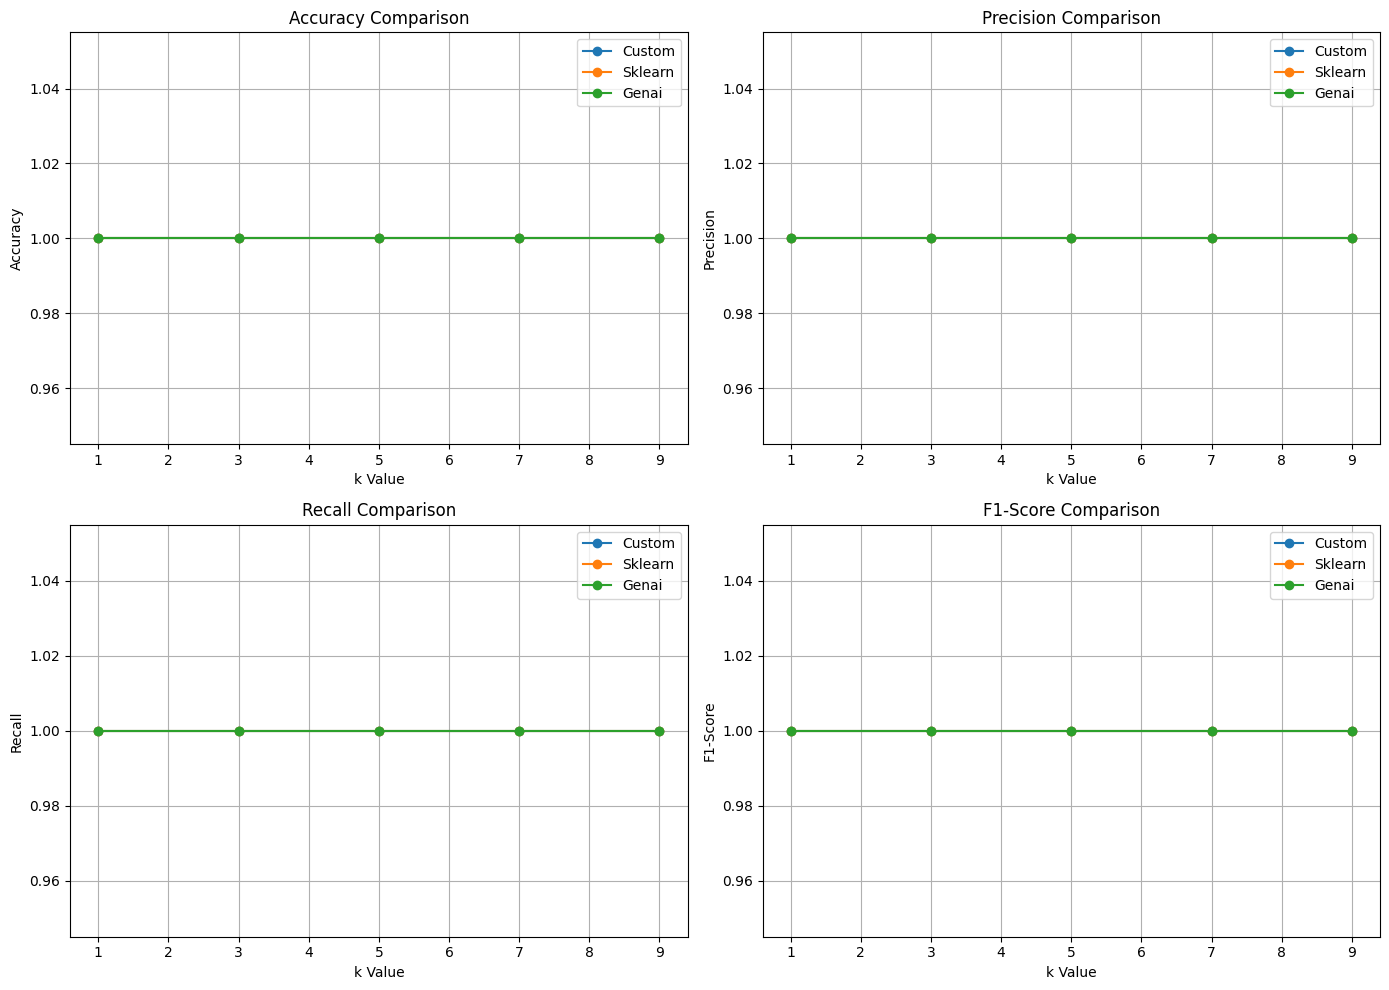

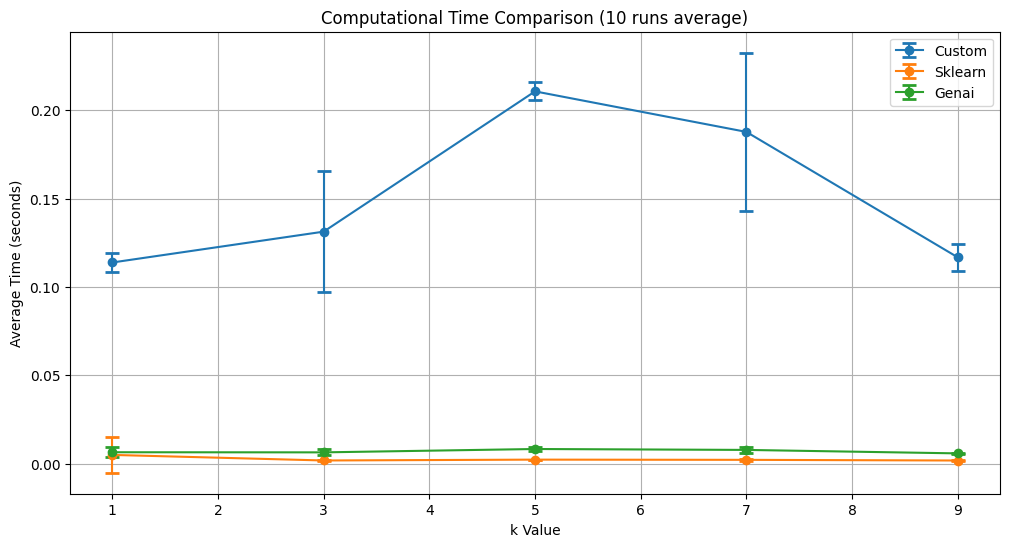


COMPREHENSIVE PERFORMANCE TABLE

Performance Comparison (Average over 10 runs):


,k,Version,Accuracy,Precision,Recall,F1-Score,Avg Time (s),Std Time (s)
0,1,Custom,1.0000,1.0000,1.0000,1.0000,0.1138,0.0051
1,1,Sklearn,1.0000,1.0000,1.0000,1.0000,0.0049,0.0101
2,1,Genai,1.0000,1.0000,1.0000,1.0000,0.0065,0.0028
3,3,Custom,1.0000,1.0000,1.0000,1.0000,0.1313,0.0342
4,3,Sklearn,1.0000,1.0000,1.0000,1.0000,0.0018,0.0003
5,3,Genai,1.0000,1.0000,1.0000,1.0000,0.0064,0.0017
6,5,Custom,1.0000,1.0000,1.0000,1.0000,0.2107,0.0051
7,5,Sklearn,1.0000,1.0000,1.0000,1.0000,0.0023,0.0001
8,5,Genai,1.0000,1.0000,1.0000,1.0000,0.0083,0.0011
9,7,Custom,1.0000,1.0000,1.0000,1.0000,0.1878,0.0448



SUMMARY BY VERSION (Averaged across all k values)


,Version,Avg Accuracy,Avg Precision,Avg Recall,Avg F1-Score,Avg Time (s)
0,Custom,1.0,1.0,1.0,1.0,0.152072
1,Sklearn,1.0,1.0,1.0,1.0,0.002586
2,Genai,1.0,1.0,1.0,1.0,0.006941



FINAL ANALYSIS
Highest Accuracy: Custom (1.0000)
Fastest Execution: Sklearn (0.0026 seconds)

PERFORMANCE COMPARISON COMPLETED


In [3]:
# Main Program - Performance Comparison
print("\n" + "="*60)
print("LAB 05: A3 - PERFORMANCE COMPARISON OF 3 KNN VERSIONS")
print("="*60)

print("\nLoading and preparing dataset...")
data = load_dataset(Config.CSV_PATH)
print("Dataset loaded:", Config.CSV_PATH)

X, y = prepare_image_dataset(
    data,
    Config.SAMPLES_PER_CLASS,
    Config.IMAGE_SIZE,
    Config.DRIVE_DIR,
    Config.DATASET_DIR,
    Config.RANDOM_STATE
)

X, y = preprocess_data(X, y, imputation_method="mean")

info = get_dataset_info(X, y)
print("\n" + "="*60)
print("DATASET INFORMATION")
print("="*60)
print("Dataset Shape:", info["shape"])
print("\nClass Distribution:")
for cls, count in info["class_distribution"].items():
    print(f"  {cls}: {count}")

print("\n" + "="*60)
print("SPLITTING DATA")
print("="*60)

X_train, X_test, y_train, y_test = split_dataset(
    X, y,
    test_size=Config.TEST_SIZE,
    random_state=Config.RANDOM_STATE
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Number of runs for averaging: {Config.NUM_RUNS}")

# Define k values to test
k_values = [1, 3, 5, 7, 9]
print(f"\nk values to test: {k_values}")

# Run performance comparison
print("\n" + "="*60)
print("STARTING PERFORMANCE COMPARISON")
print("="*60)
print("This will take some time. Please wait...")

all_results = compare_all_k_values(
    X_train, y_train, X_test, y_test,
    k_values,
    num_runs=Config.NUM_RUNS
)

print("\n" + "="*60)
print("VISUALIZING RESULTS")
print("="*60)

# Plot results
plot_performance_comparison(all_results, k_values)
plot_time_comparison(all_results, k_values)

# Create comprehensive table
print("\n" + "="*60)
print("COMPREHENSIVE PERFORMANCE TABLE")
print("="*60)

comprehensive_df = create_comprehensive_table(all_results, k_values)
print("\nPerformance Comparison (Average over 10 runs):")
display(comprehensive_df)

# Create summary by version
print("\n" + "="*60)
print("SUMMARY BY VERSION (Averaged across all k values)")
print("="*60)

version_summary = []
for version in ['custom', 'sklearn', 'genai']:
    all_acc = []
    all_prec = []
    all_rec = []
    all_f1 = []
    all_times = []

    for k in k_values:
        all_acc.extend(all_results[k][version]['accuracy'])
        all_prec.extend(all_results[k][version]['precision'])
        all_rec.extend(all_results[k][version]['recall'])
        all_f1.extend(all_results[k][version]['f1'])
        all_times.extend(all_results[k][version]['times'])

    version_summary.append({
        'Version': version.capitalize(),
        'Avg Accuracy': np.mean(all_acc),
        'Avg Precision': np.mean(all_prec),
        'Avg Recall': np.mean(all_rec),
        'Avg F1-Score': np.mean(all_f1),
        'Avg Time (s)': np.mean(all_times)
    })

summary_df = pd.DataFrame(version_summary)
display(summary_df)

# Best performing version
print("\n" + "="*60)
print("FINAL ANALYSIS")
print("="*60)

best_accuracy = summary_df.loc[summary_df['Avg Accuracy'].idxmax()]
best_time = summary_df.loc[summary_df['Avg Time (s)'].idxmin()]

print(f"Highest Accuracy: {best_accuracy['Version']} ({best_accuracy['Avg Accuracy']:.4f})")
print(f"Fastest Execution: {best_time['Version']} ({best_time['Avg Time (s)']:.4f} seconds)")

print("\n" + "="*60)
print("PERFORMANCE COMPARISON COMPLETED")
print("="*60)


In [4]:
#Unit Tests
warnings.filterwarnings('ignore')

class TestPerformanceComparison(unittest.TestCase):

    def setUp(self):
        self.X_train = np.array([[1,2], [2,3], [3,4], [8,9], [9,10], [10,11]])
        self.y_train = np.array(['A', 'A', 'A', 'B', 'B', 'B'])
        self.X_test = np.array([[2.5,3.5], [9.5,10.5]])
        self.y_test = np.array(['A', 'B'])

    def test_metrics_calculation(self):
        y_pred = ['A', 'B']
        acc, prec, rec, f1 = calculate_metrics(self.y_test, y_pred)
        self.assertEqual(acc, 1.0)
        self.assertEqual(prec, 1.0)
        self.assertEqual(rec, 1.0)
        self.assertEqual(f1, 1.0)

    def test_three_versions_output(self):
        custom_pred = custom_knn_predict(self.X_train, self.y_train, self.X_test, k=3)
        sklearn_model = train_sklearn_knn(self.X_train, self.y_train, k=3)
        sklearn_pred = get_sklearn_predictions(sklearn_model, self.X_test)
        genai_pred = genai_knn_predict(self.X_train, self.y_train, self.X_test, k=3)

        self.assertEqual(len(custom_pred), 2)
        self.assertEqual(len(sklearn_pred), 2)
        self.assertEqual(len(genai_pred), 2)

    def test_performance_measurement(self):
        results = measure_performance(
            self.X_train, self.y_train, self.X_test, self.y_test,
            k=3, num_runs=2
        )

        self.assertIn('custom', results)
        self.assertIn('sklearn', results)
        self.assertIn('genai', results)
        self.assertEqual(len(results['custom']['times']), 2)

def run_performance_tests():
    print("\n" + "="*60)
    print("RUNNING PERFORMANCE TESTS")
    print("="*60)

    loader = unittest.TestLoader()
    suite = loader.loadTestsFromTestCase(TestPerformanceComparison)
    runner = unittest.TextTestRunner(verbosity=2)
    result = runner.run(suite)

    return result.wasSuccessful()



In [5]:
# Run unit tests
tests_passed = run_performance_tests()

if tests_passed:
    print("\nALL TESTS PASSED!")
else:
    print("\nSOME TESTS FAILED")

test_metrics_calculation (__main__.TestPerformanceComparison.test_metrics_calculation) ... ok
test_performance_measurement (__main__.TestPerformanceComparison.test_performance_measurement) ... 


RUNNING PERFORMANCE TESTS

Measuring performance for k=3...
  Run 1/2 ✓
  Run 2/2

ok
test_three_versions_output (__main__.TestPerformanceComparison.test_three_versions_output) ... ok

----------------------------------------------------------------------
Ran 3 tests in 0.070s

OK


 ✓

ALL TESTS PASSED!
